<a href="https://colab.research.google.com/github/Samar97adel/Data-Analysis/blob/main/customers_data_assignment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Read Dataset

In [7]:
df = pd.read_csv('/content/drive/MyDrive/data visualization /customers_data_assignment - Copy.csv')

# Quick Peek at Data

In [9]:
df.head(10)


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
0,100001,29.0,Female,Giza,24502.0,66,4
1,100002,28.0,Male,Giza,9965.0,74,10
2,100003,19.0,Female,Cairo,8651.0,39,0
3,100004,49.0,Female,Tanta,17723.0,56,6
4,100005,49.0,Male,Mansoura,23226.0,71,6
5,100006,34.0,Female,Giza,16117.0,79,5
6,100007,28.0,Male,Aswan,14774.0,76,3
7,100008,36.0,Female,Giza,31183.0,55,4
8,100009,35.0,Male,NaN,8931.0,36,2
9,100010,56.0,Female,NaN,12168.0,30,3


In [10]:
df.tail(10)


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
20490,118766,37.0,Male,Aswan,17335.0,65,4
20491,104421,29.0,Female,Giza,24181.0,92,0
20492,101273,18.0,Male,Alexandria,16149.0,70,2
20493,100452,44.0,Female,Aswan,26728.0,80,7
20494,103520,31.0,Male,Aswan,8495.0,51,6
20495,117478,38.0,Female,Alexandria,16165.0,36,1
20496,109568,27.0,Male,Tanta,16149.0,73,4
20497,100248,34.0,Male,Alexandria,25946.0,69,4
20498,117816,55.0,Male,Aswan,11556.0,69,5
20499,101748,37.0,Male,Aswan,23253.0,67,4


In [11]:
df.sample(15)


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
20002,108669,41.0,Male,Aswan,14323.0,65,4
14359,114360,38.0,Male,Tanta,16837.0,72,2
13793,113794,28.0,Male,Mansoura,12240.0,75,3
9708,109709,28.0,Female,Giza,10765.0,68,3
14879,114880,25.0,Female,Alexandria,30451.0,51,5
940,100941,18.0,Male,Tanta,12638.0,55,3
18920,118921,44.0,Male,Giza,14641.0,23,4
17371,117372,30.0,Male,Tanta,21445.0,76,3
6643,106644,26.0,Female,Mansoura,7660.0,62,2
10598,110599,30.0,Female,Alexandria,17097.0,64,7


# Shape & Structure

In [14]:
df.shape


(20500, 7)

In [13]:
df.index


RangeIndex(start=0, stop=20500, step=1)

In [12]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'City',
 'MonthlyIncome',
 'SpendingScore',
 'MembershipYears']

# Data Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20500 entries, 0 to 20499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       20500 non-null  int64 
 1   Age              20197 non-null  object
 2   Gender           20500 non-null  object
 3   City             20191 non-null  object
 4   MonthlyIncome    20197 non-null  object
 5   SpendingScore    20500 non-null  int64 
 6   MembershipYears  20500 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1.1+ MB


In [17]:
df.isna().sum().sort_values(ascending=False)

,0
City,309
MonthlyIncome,303
Age,303
Gender,0
CustomerID,0
SpendingScore,0
MembershipYears,0


In [18]:
df.isna().mean().sort_values(ascending=False) * 100


,0
City,1.507317
MonthlyIncome,1.478049
Age,1.478049
Gender,0.000000
CustomerID,0.000000
SpendingScore,0.000000
MembershipYears,0.000000


# Duplicate Check


In [19]:
df.duplicated().sum()

np.int64(500)

In [20]:
df[df.duplicated(keep=False)]

,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
115,100116,45.0,Female,Giza,18226.0,18,3
119,100120,26.0,Female,Giza,23118.0,63,3
127,100128,40.0,Female,Tanta,20132.0,39,3
218,100219,31.0,Male,Cairo,12583.0,50,2
247,100248,34.0,Male,Alexandria,25946.0,69,4
...,...,...,...,...,...,...,...
20495,117478,38.0,Female,Alexandria,16165.0,36,1
20496,109568,27.0,Male,Tanta,16149.0,73,4
20497,100248,34.0,Male,Alexandria,25946.0,69,4
20498,117816,55.0,Male,Aswan,11556.0,69,5


In [22]:
df_nodup = df.drop_duplicates().copy()

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df_nodup

,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
0,100001,29.0,Female,Giza,24502.0,66,4
1,100002,28.0,Male,Giza,9965.0,74,10
2,100003,19.0,Female,Cairo,8651.0,39,0
3,100004,49.0,Female,Tanta,17723.0,56,6
4,100005,49.0,Male,Mansoura,23226.0,71,6
...,...,...,...,...,...,...,...
19995,119996,24.0,Female,Cairo,18994.0,81,3
19996,119997,24.0,Female,Tanta,19138.0,54,1
19997,119998,18.0,Female,Alexandria,18261.0,63,2
19998,119999,33.0,Female,Cairo,20515.0,44,3


# Categorical Columns

In [ ]:
df_nodup.info()

In [ ]:
df_nodup["Age"]

In [25]:
df_nodup["Age"].value_counts(dropna=False).sort_values(ascending=False)


,count
Age,
18.0,1075
35.0,806
33.0,786
32.0,783
38.0,773
...,...
301,1
516,1
130,1


# Data Cleaning


In [27]:
df_clean = df_nodup.copy()

In [28]:
df_clean["Age"] = pd.to_numeric(df_clean["Age"].replace({"twenty five": 25}),errors="coerce")


# Remove unrealistic ages


In [30]:
df_clean = df_clean[(df_clean["Age"] >= 18) &(df_clean["Age"] <= 100)]


# Age Groups


In [31]:
bins = [0, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

# Fill missing ages



In [32]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Outlier Detection (Age)


In [33]:
Q1 = df_clean["Age"].quantile(0.25)
Q3 = df_clean["Age"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

print(Lower, Upper)


8.5 60.5


In [34]:
df_clean = df_clean[
    (df_clean["Age"] >= Lower) &
    (df_clean["Age"] <= Upper)
]

In [38]:
outliers = df_clean[
    (df_clean["Age"] < Lower) |
    (df_clean["Age"] > Upper)
]
print("Number of outliers:", len(outliers))



Number of outliers: 0


# File Check


In [39]:
os.listdir()

print(os.path.exists("Customer_cleaned.csv"))

type(df_clean)


False


pandas.core.frame.DataFrame

# Explore Categorical Data


In [40]:
df_nodup["City"].value_counts(
    dropna=False
).sort_values(ascending=False)



,count
City,
Aswan,3322
Mansoura,3307
Tanta,3303
Giza,3258
Alexandria,3256
Cairo,3254
NaN,300


In [41]:
df_nodup["Gender"].value_counts(
    dropna=False
).sort_values(ascending=False)

,count
Gender,
Female,10004
Male,9996


# Cleaning City & Gender

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19565 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       19565 non-null  int64  
 1   Age              19565 non-null  float64
 2   Gender           19565 non-null  object 
 3   City             19270 non-null  object 
 4   MonthlyIncome    19273 non-null  object 
 5   SpendingScore    19565 non-null  int64  
 6   MembershipYears  19565 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 1.2+ MB


In [43]:
df_clean["City"] = (
    df_clean["City"]
    .astype(str)
    .str.strip()
    .str.title()
    .str.replace(",", "")
    .replace("Nan", np.nan)
)

In [45]:
df_clean["Gender"] = (
    df_clean["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
    .str.replace(",", "")
    .replace("Nan", np.nan)
)


# Monthly Income Cleaning


In [46]:
df_clean["MonthlyIncome"] = pd.to_numeric(
    df_clean["MonthlyIncome"].replace("unknown", np.nan),
    errors="coerce"
)

In [53]:
df_clean["City"].fillna(df_clean["City"].mode()[0],inplace=True)

/tmp/ipykernel_20582/895712995.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["City"].fillna(df_clean["City"].mode()[0],inplace=True)


In [54]:
df_clean["MonthlyIncome"] = (
    df_clean["MonthlyIncome"]
    .fillna(df_clean["MonthlyIncome"].median())
)

# Analysis

In [55]:
df_clean["City"].value_counts(
    dropna=False
).sort_values(ascending=False)


,count
City,
Aswan,3549
Tanta,3238
Mansoura,3218
Giza,3194
Alexandria,3188
Cairo,3178


In [56]:
df_clean["Gender"].value_counts(
    dropna=False
).sort_values(ascending=False)


,count
Gender,
Male,9788
Female,9777


In [57]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19565 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       19565 non-null  int64  
 1   Age              19565 non-null  float64
 2   Gender           19565 non-null  object 
 3   City             19565 non-null  object 
 4   MonthlyIncome    19565 non-null  float64
 5   SpendingScore    19565 non-null  int64  
 6   MembershipYears  19565 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ MB


In [58]:
df_clean["Age"].sample(10)

,Age
3425,23.0
3222,27.0
4500,27.0
5091,39.0
16935,22.0
18128,22.0
14617,49.0
3608,50.0
13860,30.0
7653,32.0


In [60]:
df_clean["Age"].value_counts().sort_values(ascending=False)

,count
Age,
18.0,1075
35.0,806
33.0,786
32.0,783
38.0,773
34.0,757
36.0,742
30.0,701
39.0,691


# Descriptive Statistics


In [61]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,19565.0,109997.022591,5773.111810,100001.0,104996.0,109996.0,114998.0,120000.0
Age,19565.0,34.579760,9.430862,18.0,28.0,34.0,41.0,60.0
MonthlyIncome,19565.0,22734.409021,100114.587671,3000.0,13462.0,18141.5,22736.0,2970394.0
SpendingScore,19565.0,59.448198,14.932830,1.0,49.0,59.0,70.0,100.0
MembershipYears,19565.0,3.556146,1.964409,0.0,2.0,4.0,5.0,11.0


In [62]:
df_clean.describe(include="object").T


,count,unique,top,freq
Gender,19565,2,Male,9788
City,19565,6,Aswan,3549


In [63]:
df_clean.corr(numeric_only=True)


,CustomerID,Age,MonthlyIncome,SpendingScore,MembershipYears
CustomerID,1.000000,-0.001564,-0.005278,-0.003914,-0.003838
Age,-0.001564,1.000000,0.009246,0.000040,0.000173
MonthlyIncome,-0.005278,0.009246,1.000000,0.000755,0.004882
SpendingScore,-0.003914,0.000040,0.000755,1.000000,-0.009035
MembershipYears,-0.003838,0.000173,0.004882,-0.009035,1.000000


# GroupBy Analysis


In [64]:
df_clean["CustomerID"] = (
    df_clean["CustomerID"]
    .astype("category")
)


In [65]:
df_clean.groupby("City").agg({
    "CustomerID": "count",
    "MonthlyIncome": ["mean", "median"],
    "SpendingScore": ["mean", "median"]
}).sort_values(
    ("MonthlyIncome", "mean"),
    ascending=False
).T


City                    Alexandria         Tanta         Cairo         Aswan  \
CustomerID    count    3188.000000   3238.000000   3178.000000   3549.000000   
MonthlyIncome mean    25403.345201  23894.653335  23320.404342  22827.574810   
              median  18141.500000  18141.500000  18141.500000  18141.500000   
SpendingScore mean       59.712045     59.693638     59.198238     59.373063   
              median     60.000000     59.000000     59.000000     60.000000   

City                          Giza      Mansoura  
CustomerID    count    3194.000000   3218.000000  
MonthlyIncome mean    21916.176894  19053.568521  
              median  18141.500000  18141.500000  
SpendingScore mean       59.351597     59.365444  
              median     59.000000     60.000000

In [66]:
df_clean.groupby("Age").agg({
    "CustomerID": "count"
}).sort_values(
    "CustomerID",
    ascending=False
)

,CustomerID
Age,
18.0,1075
35.0,806
33.0,786
32.0,783
38.0,773
34.0,757
36.0,742
30.0,701
39.0,691


# Outlier Scan (Age)


In [68]:
s1 = df_clean["Age"].dropna()

q1 = s1.quantile(0.25)
q3 = s1.quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(q1)
print(q3)
print(iqr)
print(lower)
print(upper)



28.0
41.0
13.0
8.5
60.5


In [69]:
df_clean[df_clean["Age"] < lower]


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears


In [70]:
df_clean[df_clean["Age"] > upper]


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears


# Outlier Scan (Monthly Income)


In [71]:
s2 = df_clean["MonthlyIncome"].dropna()

q1 = s2.quantile(0.25)
q3 = s2.quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(q1)
print(q3)
print(iqr)
print(lower)
print(upper)

13462.0
22736.0
9274.0
-449.0
36647.0


In [72]:
df_clean[df_clean["MonthlyIncome"] < lower]


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears


In [73]:
df_clean[df_clean["MonthlyIncome"] > upper]


,CustomerID,Age,Gender,City,MonthlyIncome,SpendingScore,MembershipYears
10,100011,36.0,Female,Mansoura,44053.0,66,3
155,100156,47.0,Female,Cairo,37773.0,58,6
235,100236,43.0,Male,Aswan,728716.0,77,2
368,100369,35.0,Female,Alexandria,1437822.0,61,6
393,100394,42.0,Female,Tanta,38062.0,65,5
...,...,...,...,...,...,...,...
19212,119213,18.0,Female,Tanta,2756538.0,38,6
19544,119545,38.0,Female,Alexandria,37296.0,83,4
19689,119690,32.0,Female,Aswan,38642.0,57,4
19770,119771,34.0,Female,Cairo,43017.0,65,3


# Visualization


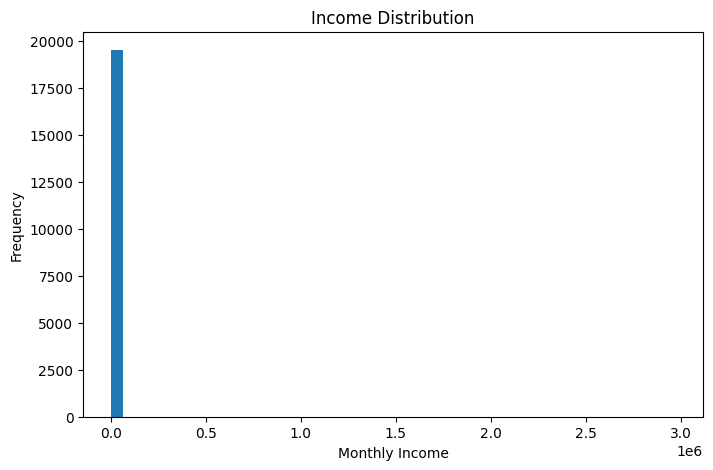

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["MonthlyIncome"],
    bins=50
)

plt.title("Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()


# Spending Score

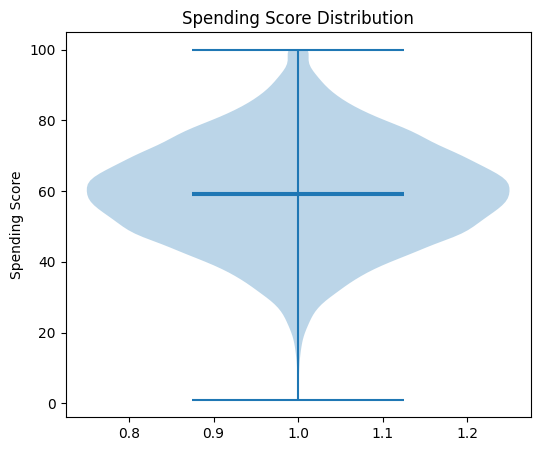

In [75]:
plt.figure(figsize=(6, 5))

plt.violinplot(
    df_clean["SpendingScore"],
    showmeans=True,
    showmedians=True
)

plt.title("Spending Score Distribution")
plt.ylabel("Spending Score")

plt.show()


# Export Clean Data


In [76]:
from google.colab import files

df_clean.to_csv(
    "Customer_cleaned.csv",
    index=False
)

files.download("Customer_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>